# EDA: Exploratory Data Analysis

Анализ данных для моделирования IC50, CC50 и SI.

**Файл:** data.xlsx, лист Sheet1
**Дата:** 2026-08-13


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = 'data.xlsx'
SHEET_NAME = 'Sheet1'
RANDOM_STATE = 42
ASSETS_DIR = 'assets'

try:
    import seaborn as sns
    sns.set_style('whitegrid')
    sns.set_context('notebook', font_scale=0.9)
    plt.rcParams['figure.figsize'] = (8, 5)
    plt.rcParams['font.size'] = 10
except ImportError:
    pass


In [2]:
import os
os.makedirs(ASSETS_DIR, exist_ok=True)


In [3]:
df = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)
print(f'Размерность: {df.shape[0]} строк x {df.shape[1]} колонок')
display(df.head())


Размерность: 1001 строк x 214 колонок


,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,...,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,...,0,0,0,0,0,0,0,0,0,0


In [4]:
target_cols = ['IC50, mM', 'CC50, mM', 'SI']
feat_cols_all = [c for c in df.columns if c not in target_cols + ['Unnamed: 0']]

const_cols = [c for c in feat_cols_all if df[c].nunique() == 1]
print(f'Константные признаки ({len(const_cols)}): {const_cols}')

missing_list = [(c, int(df[c].isnull().sum())) for c in feat_cols_all if df[c].isnull().sum() > 0]
print(f'Колонки с пропусками ({len(missing_list)}): {missing_list}')


Константные признаки (18): ['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'fr_N_O', 'fr_SH', 'fr_azide', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo', 'fr_dihydropyridine', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam', 'fr_nitroso', 'fr_phos_acid', 'fr_phos_ester', 'fr_prisulfonamd', 'fr_thiocyan']
Колонки с пропусками (12): [('MaxPartialCharge', 3), ('MinPartialCharge', 3), ('MaxAbsPartialCharge', 3), ('MinAbsPartialCharge', 3), ('BCUT2D_MWHI', 3), ('BCUT2D_MWLOW', 3), ('BCUT2D_CHGHI', 3), ('BCUT2D_CHGLO', 3), ('BCUT2D_LOGPHI', 3), ('BCUT2D_LOGPLOW', 3), ('BCUT2D_MRHI', 3), ('BCUT2D_MRLOW', 3)]


In [5]:
for col in target_cols:
    s = df[col]
    print(f'{col}: mean={s.mean():.2f}, median={s.median():.2f}, std={s.std():.2f}')
    print(f'  min={s.min():.4f}, max={s.max():.2f}, skew={s.skew():.2f}, kurt={s.kurtosis():.2f}')


IC50, mM: mean=222.81, median=46.59, std=402.17
  min=0.0035, max=4128.53, skew=3.67, kurt=22.45
CC50, mM: mean=589.11, median=411.04, std=642.87
  min=0.7008, max=4538.98, skew=1.97, kurt=5.68
SI: mean=72.51, median=3.85, std=684.48
  min=0.0115, max=15620.60, skew=18.01, kurt=361.42


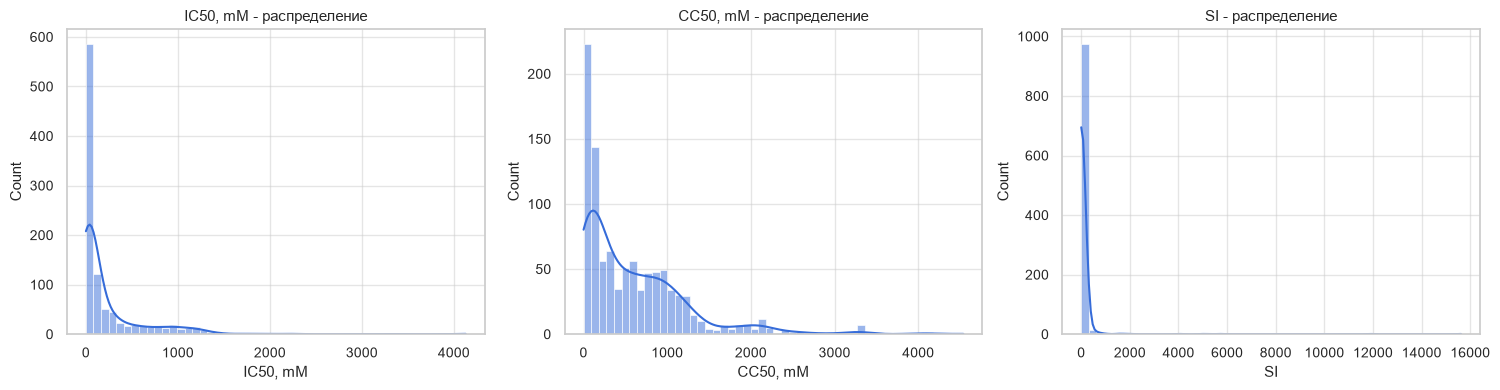

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for col, ax in zip(target_cols, axes):
    sns.histplot(df[col].dropna(), bins=50, ax=ax, kde=True)
    ax.set_title(f'{col} - распределение')
    ax.set_xlabel(col)
plt.tight_layout()
plt.savefig(f'{ASSETS_DIR}/eda_targets_dist.png', dpi=150, bbox_inches='tight')
plt.show()


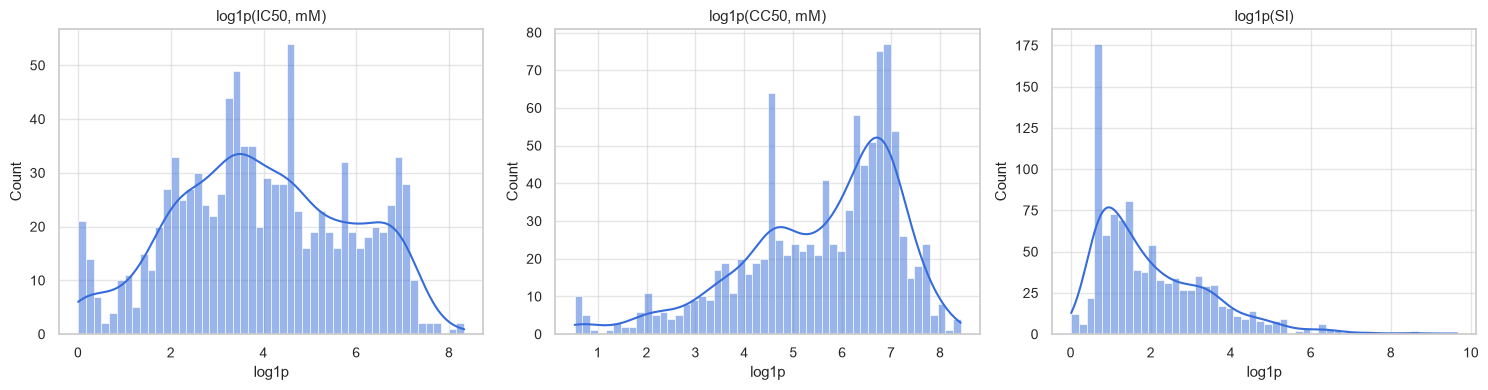

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for col, ax in zip(target_cols, axes):
    log_data = np.log1p(df[col])
    sns.histplot(log_data, bins=50, ax=ax, kde=True)
    ax.set_title(f'log1p({col})')
    ax.set_xlabel('log1p')
plt.tight_layout()
plt.savefig(f'{ASSETS_DIR}/eda_targets_log_dist.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
feat_cols = [c for c in feat_cols_all if c not in const_cols]
df_feat = df[feat_cols + target_cols].copy()

for target in target_cols:
    corr = df_feat.corr()[target].drop([target])
    top = corr.abs().sort_values(ascending=False).head(5)
    print(f'Top-5 для {target}:')
    for f, v in top.items():
        print(f'  {f}: {v:.3f}')


Top-5 для IC50, mM:
  CC50, mM: 0.521
  VSA_EState4: 0.274
  Chi2n: 0.257
  PEOE_VSA7: 0.256
  Chi2v: 0.249
Top-5 для CC50, mM:
  IC50, mM: 0.521
  MolMR: 0.310
  LabuteASA: 0.309
  MolWt: 0.306
  ExactMolWt: 0.306
Top-5 для SI:
  BalabanJ: 0.163
  fr_NH2: 0.160
  RingCount: 0.124
  fr_Al_COO: 0.102
  fr_COO: 0.101


In [9]:
ratio = df['CC50, mM'] / df['IC50, mM']
match_count = (df['SI'] == ratio).sum()
print(f'SI == CC50/IC50: {match_count}/{len(df)} совпадений')
print(f'Несовпадений: {len(df) - match_count}')


SI == CC50/IC50: 410/1001 совпадений
Несовпадений: 591


In [10]:
print('=== ИТОГИ EDA ===')
print(f'Данные: {df.shape[0]} строк, {df.shape[1]} колонок')
print(f'Признаки: {len(feat_cols)}, константные удалены: {len(const_cols)}')
print(f'Пропуски: {sum(v for _, v in missing_list)} в {len(missing_list)} колонках')
print(f'SI != CC50/IC50: {len(df) - match_count} наблюдений')


=== ИТОГИ EDA ===
Данные: 1001 строк, 214 колонок
Признаки: 192, константные удалены: 18
Пропуски: 36 в 12 колонках
SI != CC50/IC50: 591 наблюдений
